## ADEP

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv("../data/interim/base_datos_adep_2022-2025.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 61358 entries, 0 to 61357
Data columns (total 23 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sexo       61358 non-null  float64
 1   edad       61358 non-null  float64
 2   sin_01     61358 non-null  float64
 3   sin_2      61358 non-null  float64
 4   sin_3      61358 non-null  float64
 5   sin_4      61357 non-null  float64
 6   sin_5      61358 non-null  float64
 7   sin_6      61358 non-null  float64
 8   sin_7      61358 non-null  float64
 9   sin_8      61357 non-null  float64
 10  sin_9      61358 non-null  float64
 11  sin_010    61358 non-null  float64
 12  sin_011    61358 non-null  float64
 13  sin_012    61358 non-null  float64
 14  sin_013    61358 non-null  float64
 15  sin_014    61358 non-null  float64
 16  sin_015    61358 non-null  float64
 17  sin_016    61358 non-null  float64
 18  sin_017    61358 non-null  float64
 19  sin_018    61358 non-null  float64
 20  sin_019    61358 

In [3]:
df["edad"]= df["edad"].astype(int)
df = df[(df["edad"]>0) & (df["edad"]<=19)]
df.head(5)

,sexo,edad,sin_01,sin_2,sin_3,sin_4,sin_5,sin_6,sin_7,sin_8,...,sin_012,sin_013,sin_014,sin_015,sin_016,sin_017,sin_018,sin_019,sin_20,fecha_reg
2,1.0,16,1.0,3.0,2.0,1.0,2.0,2.0,2.0,3.0,...,2.0,1.0,2.0,1.0,2.0,2.0,2.0,1.0,3.0,01/02/2022 02:46
6,1.0,18,2.0,2.0,3.0,2.0,3.0,2.0,3.0,2.0,...,2.0,3.0,2.0,2.0,2.0,2.0,2.0,3.0,3.0,01/02/2022 06:42
14,1.0,15,1.0,0.0,2.0,0.0,3.0,3.0,3.0,0.0,...,2.0,2.0,3.0,1.0,2.0,2.0,3.0,3.0,3.0,01/02/2022 16:41
15,1.0,19,1.0,1.0,0.0,0.0,3.0,2.0,2.0,0.0,...,1.0,1.0,3.0,2.0,1.0,2.0,3.0,2.0,3.0,01/02/2022 16:59
19,1.0,15,0.0,3.0,2.0,3.0,2.0,3.0,3.0,3.0,...,2.0,3.0,3.0,0.0,3.0,0.0,2.0,3.0,3.0,01/02/2022 19:11


In [4]:
df.info()

<class 'pandas.DataFrame'>
Index: 22511 entries, 2 to 61357
Data columns (total 23 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sexo       22511 non-null  float64
 1   edad       22511 non-null  int64  
 2   sin_01     22511 non-null  float64
 3   sin_2      22511 non-null  float64
 4   sin_3      22511 non-null  float64
 5   sin_4      22510 non-null  float64
 6   sin_5      22511 non-null  float64
 7   sin_6      22511 non-null  float64
 8   sin_7      22511 non-null  float64
 9   sin_8      22511 non-null  float64
 10  sin_9      22511 non-null  float64
 11  sin_010    22511 non-null  float64
 12  sin_011    22511 non-null  float64
 13  sin_012    22511 non-null  float64
 14  sin_013    22511 non-null  float64
 15  sin_014    22511 non-null  float64
 16  sin_015    22511 non-null  float64
 17  sin_016    22511 non-null  float64
 18  sin_017    22511 non-null  float64
 19  sin_018    22511 non-null  float64
 20  sin_019    22511 non-n

### Pregunta #1: Cuánto tiempo llegaste a sentirte solo en la semana?

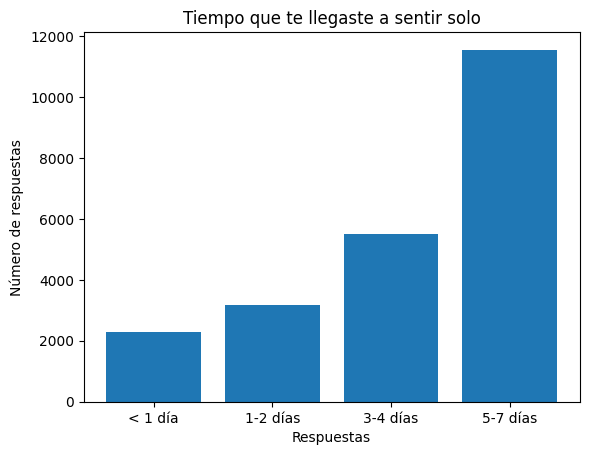

In [8]:
respuestas = ["< 1 día","1-2 días","3-4 días","5-7 días"]

r0= (df["sin_014"] == 0).sum()
r1= (df["sin_014"] == 1).sum()
r2= (df["sin_014"] == 2).sum()
r3= (df["sin_014"] == 3).sum()

num_r = [r0,r1,r2,r3]
conteo = df["sin_014"].value_counts().sort_index()

plt.bar(respuestas,conteo)
plt.title("Tiempo que te llegaste a sentir solo")
plt.xlabel("Respuestas")
plt.ylabel("Número de respuestas")
plt.show()

### Pregunta #2: Cuántas personas participaron cada año? (2022-2025)

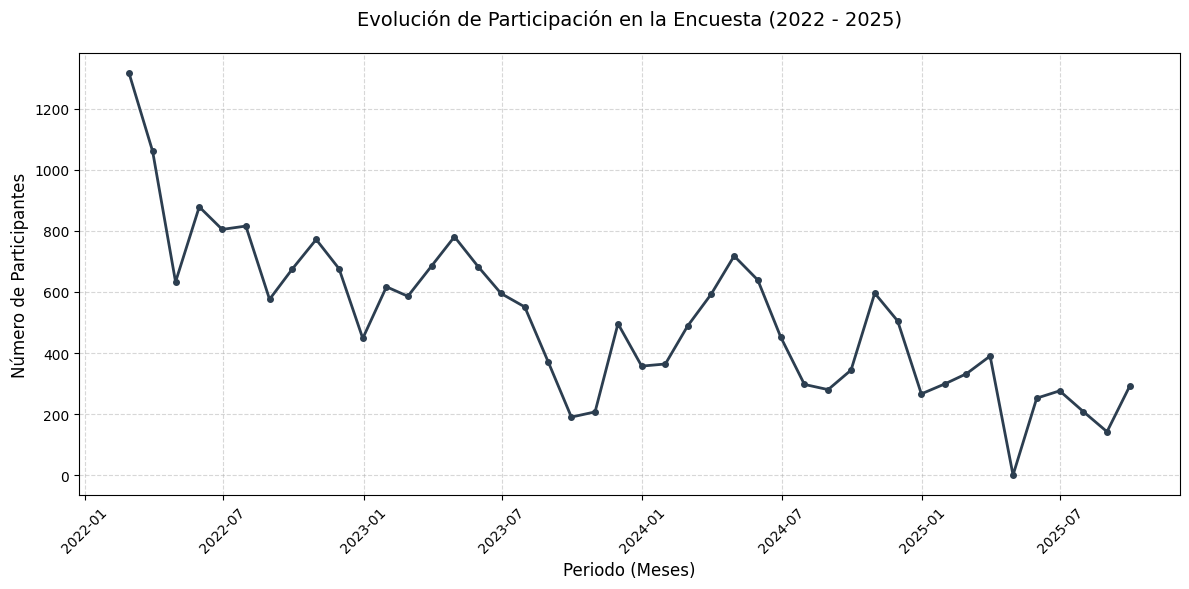

In [9]:
df["fecha_reg"] = pd.to_datetime(df["fecha_reg"], dayfirst=True)
df = df.sort_values("fecha_reg")

evolucion_mensual = df.resample('ME', on='fecha_reg').size()


plt.figure(figsize=(12, 6))
plt.plot(evolucion_mensual.index, evolucion_mensual.values, 
         color='#2c3e50', linewidth=2, marker='o', markersize=4, label='Nuevos Participantes')

plt.title('Evolución de Participación en la Encuesta (2022 - 2025)', fontsize=14, pad=20)
plt.xlabel('Periodo (Meses)', fontsize=12)
plt.ylabel('Número de Participantes', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Pregunta #3: Cuántas días a la semana sienten que disfrutaron de la vida?

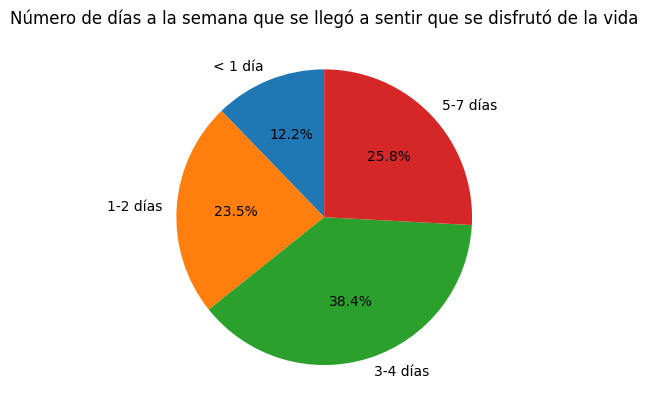

In [10]:
respuestas = ["< 1 día","1-2 días","3-4 días","5-7 días"]

r0= (df["sin_016"] == 0).sum()
r1= (df["sin_016"] == 1).sum()
r2= (df["sin_016"] == 2).sum()
r3= (df["sin_016"] == 3).sum()

num_r = [r0,r1,r2,r3]
conteo = df["sin_016"].value_counts().sort_index()

plt.pie(conteo, 
    labels=respuestas,
    autopct='%1.1f%%',
    startangle=90)
plt.title("Número de días a la semana que se llegó a sentir que se disfrutó de la vida")
plt.show()

### Pregunta #4: Cuánto tiempo te llegaste a sentir deprimido en la semana?

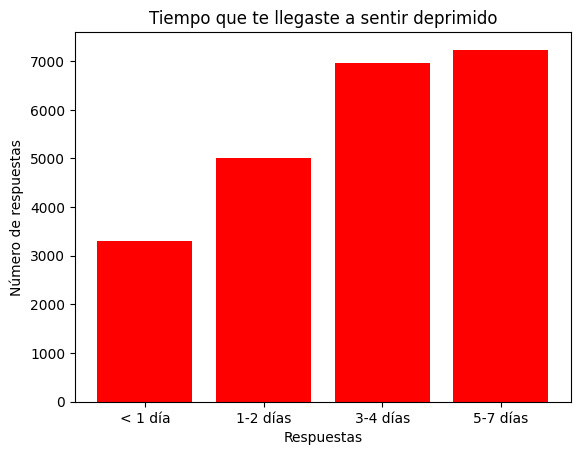

In [11]:
respuestas = ["< 1 día","1-2 días","3-4 días","5-7 días"]

r0= (df["sin_6"] == 0).sum()
r1= (df["sin_6"] == 1).sum()
r2= (df["sin_6"] == 2).sum()
r3= (df["sin_6"] == 3).sum()

num_r = [r0,r1,r2,r3]
conteo = df["sin_6"].value_counts().sort_index()

plt.bar(respuestas,conteo, color='red')
plt.title("Tiempo que te llegaste a sentir deprimido")
plt.xlabel("Respuestas")
plt.ylabel("Número de respuestas")
plt.show()

In [12]:
df.to_csv('../data/processed/base_datos_adep_2022-2025.csv', index=False, encoding='utf-8')

## ENSANUT

In [15]:
df = pd.read_csv("../data/interim/base_datos_ensanut_2021-2024.csv",on_bad_lines='skip')
df.head(5)

/tmp/ipykernel_145227/4011494324.py:1: DtypeWarning: Columns (0: D0302E1, 1: d0302e, 2: d0303e, 3: D0307E1, 4: d0307e, 5: d0310, 6: d0310t, 7: D0311E1, 8: d0311e, 9: nota3_21, 10: d0326t, 11: d0326p, 12: d0329e, 13: d0332, 14: d0502, 15: d0503, 16: d0504, 17: d0505, 18: d0506, 19: d0507, 20: d0510pc, 21: d0510pd, 22: d0510sc, 23: d0510sd, 24: d0511rc, 25: d0511rd, 26: d0511pc, 27: d0511pd, 28: d0511sc, 29: d0511sd, 30: d0511tc, 31: d0511td, 32: d0512uc, 33: d0512ud, 34: d0513uc, 35: d0513ud, 36: d0514pc, 37: d0514pd, 38: d0514sc, 39: d0514sd, 40: d0514uc, 41: d0514ud, 42: d0515pc, 43: d0515pd, 44: d0515sc, 45: d0515sd, 46: d0515tc, 47: d0515td, 48: d0516oa4, 49: d0516oa5, 50: d0516ob4, 51: d0516ob5, 52: d0516oc4, 53: d0516oc5, 54: d0603, 55: d0604, 56: d0705e, 57: d0706a, 58: d0706b, 59: d0706c, 60: d0706d, 61: d0706e, 62: d0706f, 63: d0706g, 64: d0706h, 65: d0706i, 66: d0706ja, 67: d0706jb, 68: d0706je, 69: D0803A, 70: D0803B, 71: D0803C, 72: D0803D, 73: D0803E1, 74: D0803F, 75: D0803

,FOLIO_I,FOLIO_INT,hora_ini_1,fecha_ini_1,hora_fin_1,fecha_fin_1,tiempo1,resultado_1,hora_ini_2,fecha_ini_2,...,d05072,ageb,intp,intsel,d0517_1,d0517_2,d0517_3,d0517_4,d0517_5,d0517esp
0,2021_01001013,2021_01001013_05,14:28:44,07/10/2021,14:41:45,07/10/2021,13,1,,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021_01001019,2021_01001019_04,14:01:38,09/10/2021,14:13:48,09/10/2021,12,1,,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021_01001020,2021_01001020_04,17:25:23,07/10/2021,17:26:21,07/10/2021,1,5,18:53:50,07/10/2021,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021_01001048,2021_01001048_05,12:53:20,08/10/2021,12:59:31,08/10/2021,6,1,,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021_01001052,2021_01001052_05,20:31:50,08/10/2021,20:44:52,08/10/2021,13,1,,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
df = df[['edad','sexo','fecha_ini','d0601a','d0601b','d0601c','d0601d','d0601e','d0601f','d0601g']]
df.head(5)

,edad,sexo,fecha_ini,d0601a,d0601b,d0601c,d0601d,d0601e,d0601f,d0601g
0,19,1,07/10/2021,1,1,1,1,2,4,1
1,12,1,09/10/2021,1,1,1,2,1,4,2
2,17,1,07/10/2021,1,1,1,2,3,4,1
3,15,1,08/10/2021,1,1,1,3,2,4,2
4,15,2,08/10/2021,2,1,2,3,1,2,2


In [17]:
print(df.isnull().mean())

edad         0.0
sexo         0.0
fecha_ini    0.0
d0601a       0.0
d0601b       0.0
d0601c       0.0
d0601d       0.0
d0601e       0.0
d0601f       0.0
d0601g       0.0
dtype: float64


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13353 entries, 0 to 13352
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   edad       13353 non-null  int64
 1   sexo       13353 non-null  int64
 2   fecha_ini  13353 non-null  str  
 3   d0601a     13353 non-null  int64
 4   d0601b     13353 non-null  int64
 5   d0601c     13353 non-null  int64
 6   d0601d     13353 non-null  int64
 7   d0601e     13353 non-null  int64
 8   d0601f     13353 non-null  int64
 9   d0601g     13353 non-null  int64
dtypes: int64(9), str(1)
memory usage: 1.0 MB


In [19]:
df = df.rename(columns={'fecha_ini':'fecha','d0601a':'¿Sentías como si no pudieras quitarte de encima la tristeza?','d0601b':'¿Te costaba concentrarte en lo que estabas haciendo?','d0601c':'¿Te sentiste deprimido/a?','d0601d':'¿Te parecía que todo lo que hacías era un esfuerzo?','d0601e':'¿No dormiste bien?','d0601f':'¿Disfrutaste de la vida?','d0601g':'¿Te sentiste triste?',})

In [20]:
df.head(5)

,edad,sexo,fecha,¿Sentías como si no pudieras quitarte de encima la tristeza?,¿Te costaba concentrarte en lo que estabas haciendo?,¿Te sentiste deprimido/a?,¿Te parecía que todo lo que hacías era un esfuerzo?,¿No dormiste bien?,¿Disfrutaste de la vida?,¿Te sentiste triste?
0,19,1,07/10/2021,1,1,1,1,2,4,1
1,12,1,09/10/2021,1,1,1,2,1,4,2
2,17,1,07/10/2021,1,1,1,2,3,4,1
3,15,1,08/10/2021,1,1,1,3,2,4,2
4,15,2,08/10/2021,2,1,2,3,1,2,2


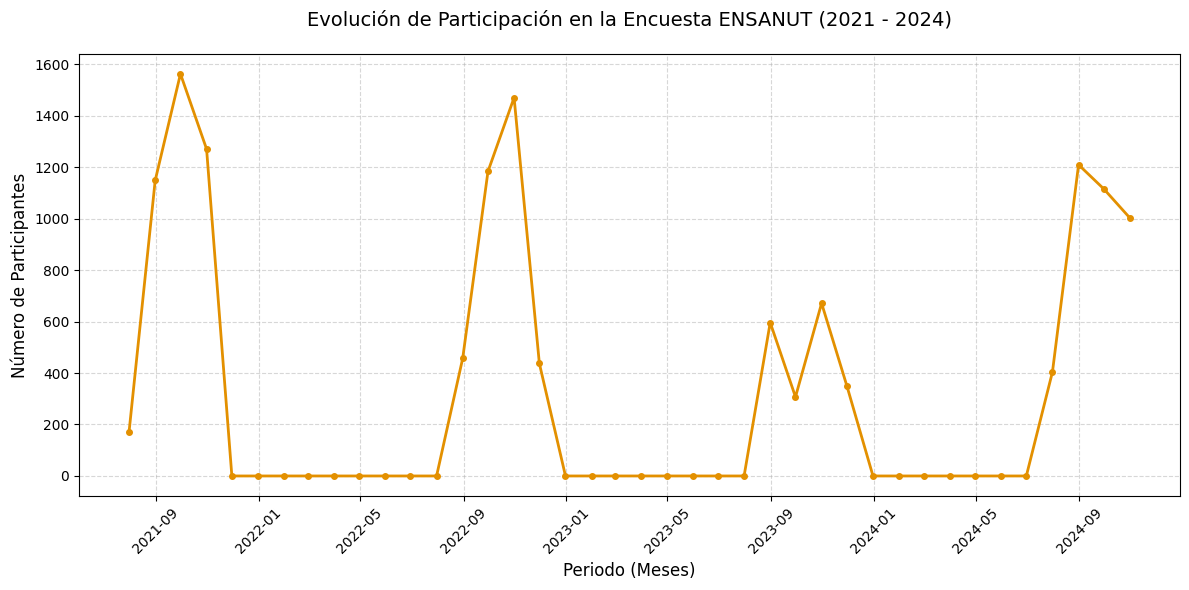

In [21]:
df["fecha"] = pd.to_datetime(df["fecha"], dayfirst=True)
df = df.sort_values("fecha")

evolucion_mensual = df.resample('ME', on='fecha').size()


plt.figure(figsize=(12, 6))
plt.plot(evolucion_mensual.index, evolucion_mensual.values, 
         color="#e39000", linewidth=2, marker='o', markersize=4, label='Nuevos Participantes')

plt.title('Evolución de Participación en la Encuesta ENSANUT (2021 - 2024)', fontsize=14, pad=20)
plt.xlabel('Periodo (Meses)', fontsize=12)
plt.ylabel('Número de Participantes', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

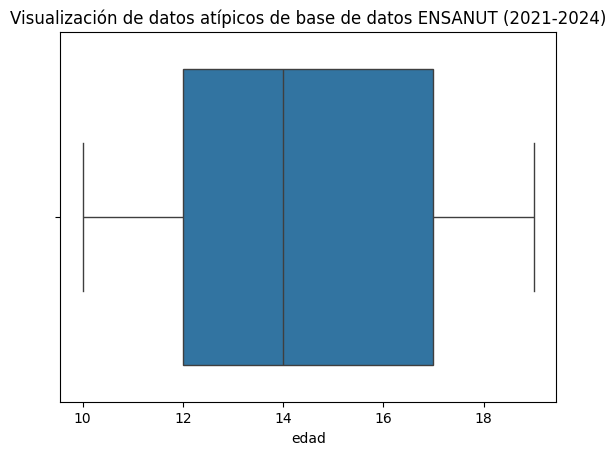

In [22]:
sns.boxplot(x=df['edad'])
plt.title('Visualización de datos atípicos de base de datos ENSANUT (2021-2024)')
plt.show()

In [23]:
valor_maximo = df['edad'].max()
print(f"Edad más alta: {valor_maximo}")

Edad más alta: 19


In [24]:
valor_minimo = df['edad'].min()
print(f"Edad más baja: {valor_minimo}")

Edad más baja: 10


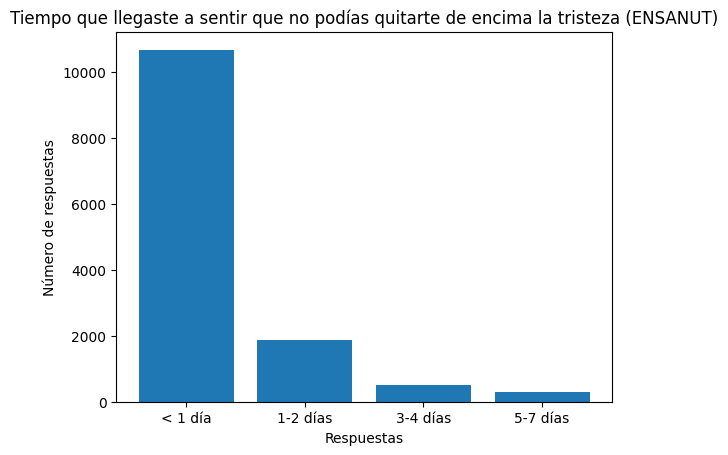

In [25]:
respuestas = ["< 1 día","1-2 días","3-4 días","5-7 días"]

r1= (df["¿Sentías como si no pudieras quitarte de encima la tristeza?"] == 1).sum()
r2= (df["¿Sentías como si no pudieras quitarte de encima la tristeza?"] == 2).sum()
r3= (df["¿Sentías como si no pudieras quitarte de encima la tristeza?"] == 3).sum()
r4= (df["¿Sentías como si no pudieras quitarte de encima la tristeza?"] == 4).sum()

num_r = [r1,r2,r3,r4]
conteo = df["¿Sentías como si no pudieras quitarte de encima la tristeza?"].value_counts().sort_index()

plt.bar(respuestas,conteo)
plt.title("Tiempo que llegaste a sentir que no podías quitarte de encima la tristeza (ENSANUT)")
plt.xlabel("Respuestas")
plt.ylabel("Número de respuestas")
plt.show()

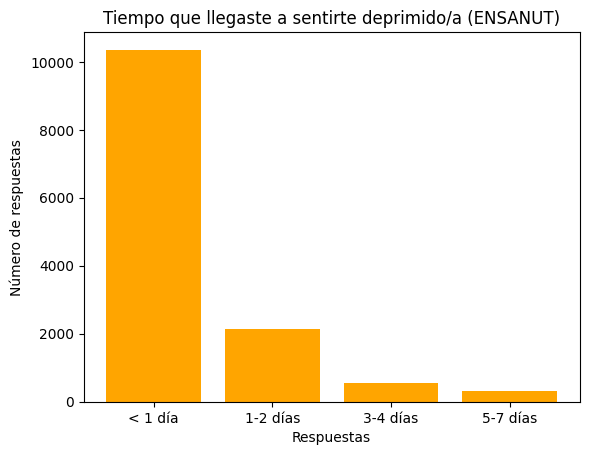

In [26]:
respuestas = ["< 1 día","1-2 días","3-4 días","5-7 días"]

r1= (df["¿Te sentiste deprimido/a?"] == 1).sum()
r2= (df["¿Te sentiste deprimido/a?"] == 2).sum()
r3= (df["¿Te sentiste deprimido/a?"] == 3).sum()
r4= (df["¿Te sentiste deprimido/a?"] == 4).sum()

num_r = [r1,r2,r3,r4]
conteo = df["¿Te sentiste deprimido/a?"].value_counts().sort_index()

plt.bar(respuestas,conteo, color='orange')
plt.title("Tiempo que llegaste a sentirte deprimido/a (ENSANUT)")
plt.xlabel("Respuestas")
plt.ylabel("Número de respuestas")
plt.show()

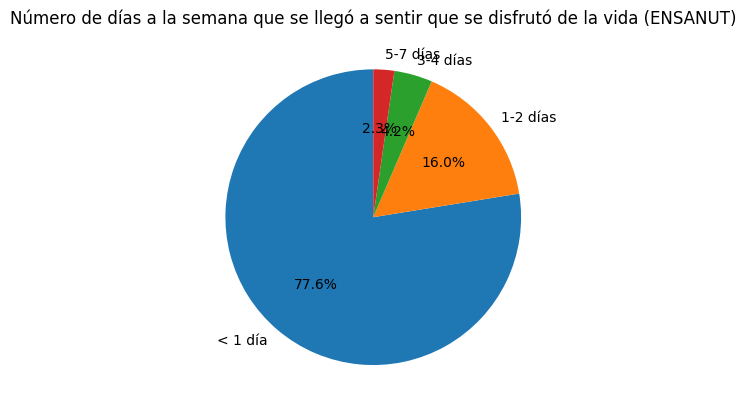

In [27]:
respuestas = ["< 1 día","1-2 días","3-4 días","5-7 días"]

r1= (df["¿Te sentiste deprimido/a?"] == 1).sum()
r2= (df["¿Te sentiste deprimido/a?"] == 2).sum()
r3= (df["¿Te sentiste deprimido/a?"] == 3).sum()
r4= (df["¿Te sentiste deprimido/a?"] == 4).sum()

num_r = [r1,r2,r3,r4]
conteo = df["¿Te sentiste deprimido/a?"].value_counts().sort_index()

plt.pie(conteo, 
    labels=respuestas,
    autopct='%1.1f%%',
    startangle=90)
plt.title("Número de días a la semana que se llegó a sentir que se disfrutó de la vida (ENSANUT)")
plt.show()

In [28]:
df.to_csv('../data/processed/base_datos_ensanut_2021-2024.csv', index=False, encoding='utf-8')